<a href="https://colab.research.google.com/github/Huyen-005/THDeepLearning/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


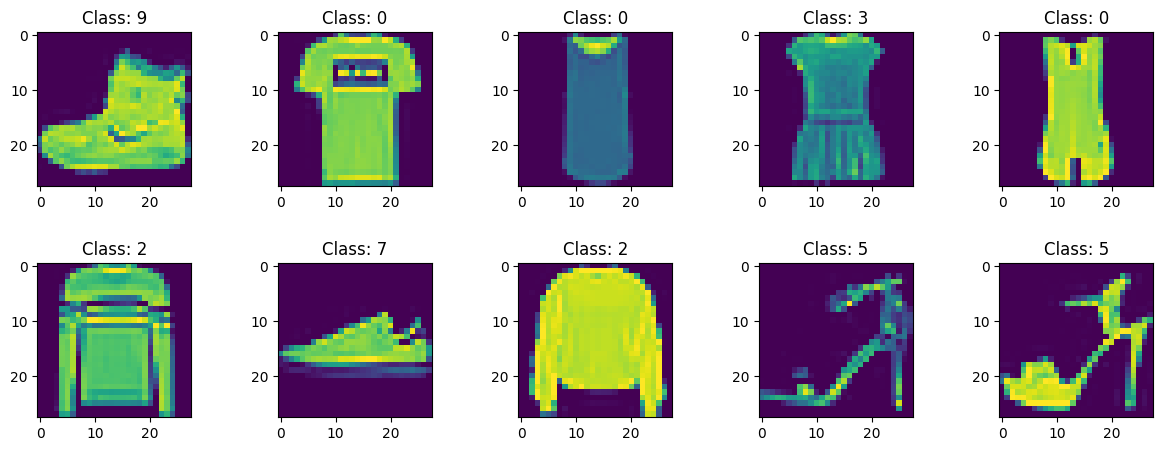

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8193 - loss: 0.5082 - val_accuracy: 0.8592 - val_loss: 0.3870
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8659 - loss: 0.3699 - val_accuracy: 0.8692 - val_loss: 0.3611
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8802 - loss: 0.3319 - val_accuracy: 0.8698 - val_loss: 0.3593
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8868 - loss: 0.3066 - val_accuracy: 0.8767 - val_loss: 0.3348
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8938 - loss: 0.2871 - val_accuracy: 0.8823 - val_loss: 0.3271
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8995 - loss: 0.2728 - val_accuracy: 0.8827 - val_loss: 0.3348
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9036 - loss: 0.2573 - val_accuracy: 0.8860 - val_loss: 0.3133
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9073 - loss: 0.2456

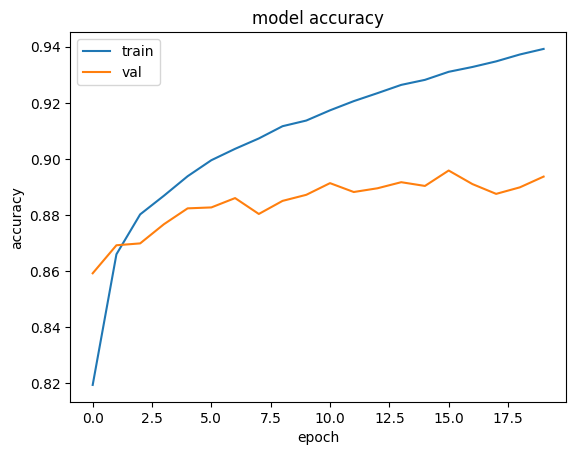

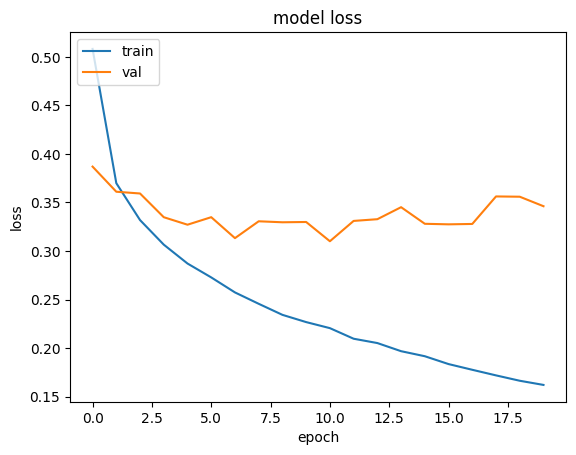

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [11]:
#install required libraries
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
#from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: "+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)
# Vẽ biểu đồ độ chính xác (Accuracy)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Vẽ biểu đồ độ mất mát (Loss)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

Kích thước tập train: (50000, 3072)
Số lớp: 10


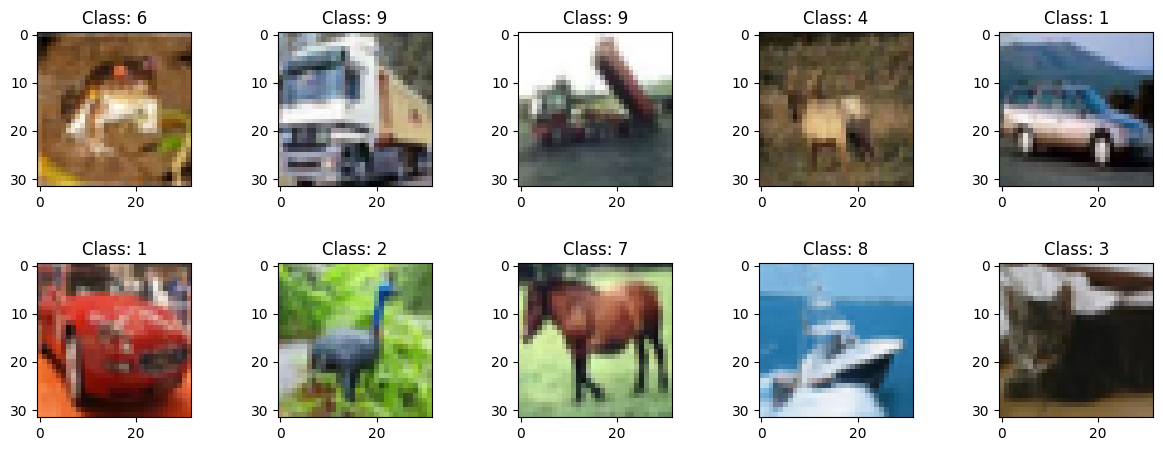

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.3249 - loss: 1.8474 - val_accuracy: 0.3578 - val_loss: 1.7965
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.3965 - loss: 1.6759 - val_accuracy: 0.4134 - val_loss: 1.6402
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.4295 - loss: 1.5896 - val_accuracy: 0.4262 - val_loss: 1.5954
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4484 - loss: 1.5394 - val_accuracy: 0.4464 - val_loss: 1.5551
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.4636 - loss: 1.5003 - val_accuracy: 0.4676 - val_loss: 1.4871
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.4733 - loss: 1.4717 - val_accuracy: 0.4684 - val_loss: 1.5100
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4826 - loss: 1.4439 - val_accuracy: 0.4870 - val_loss: 1.4719
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4920 -

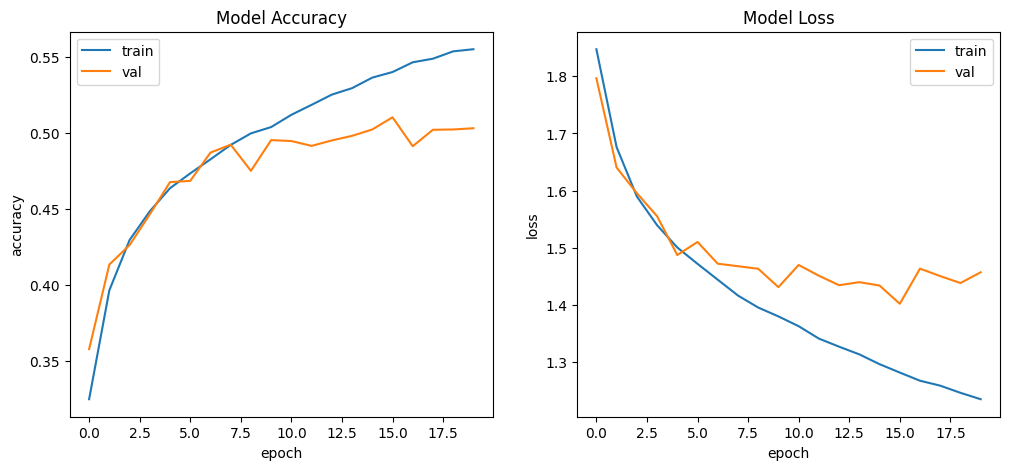

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Dự báo mẫu 0: 3 | Thực tế: 3
Dự báo mẫu 9: 1 | Thực tế: 1


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.preprocessing import MinMaxScaler

# 1. Tải bộ dữ liệu CIFAR-10
# (Ảnh màu 32x32x3, gồm 10 lớp: máy bay, ô tô, chim, mèo, hươu, chó, ếch, ngựa, tàu, xe tải)
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Tiền xử lý dữ liệu
# Ảnh CIFAR-10 là 32x32x3 = 3072 đặc trưng
X_train = X_train.reshape(50000, 3072).astype('float32') / 255.0
X_test = X_test.reshape(10000, 3072).astype('float32') / 255.0

print('Kích thước tập train:', X_train.shape)
print('Số lớp:', len(np.unique(y_train)))

# 3. Trực quan hóa dữ liệu (Hiển thị 10 ảnh đầu tiên)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(32, 32, 3))
    ax[i].title.set_text("Class: " + str(y_train[i][0]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# 4. Xây dựng mô hình ANN
model = Sequential([
    Dense(512, input_shape=(3072,), kernel_initializer='uniform', activation='relu'),
    Dense(256, kernel_initializer='uniform', activation='relu'),
    Dense(10, kernel_initializer='uniform', activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 5. Huấn luyện mô hình
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

# 6. Trực quan hóa kết quả (Đồ thị đầy đủ)
# Biểu đồ Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

# 7. Dự báo
preds = model.predict(X_test[:10])

print("Dự báo mẫu 0:", np.argmax(preds[0]), "| Thực tế:", y_test[0][0])
print("Dự báo mẫu 9:", np.argmax(preds[9]), "| Thực tế:", y_test[9][0]) # Sửa 10 thành 9

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Đang huấn luyện...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9302 - loss: 0.2424 - val_accuracy: 0.9710 - val_loss: 0.1047
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9701 - loss: 0.1018 - val_accuracy: 0.9762 - val_loss: 0.0828
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9799 - loss: 0.0672 - val_accuracy: 0.9735 - val_loss: 0.0880
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9854 - loss: 0.0479 - val_accuracy: 0.9797 - val_loss: 0.0740
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9882 - loss: 0.0366 - val_accuracy: 0.9820 - val_loss: 0.0673
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9916 - loss: 0.0259 - val_accuracy: 0.9802 - val_loss: 0.0767
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9937 - loss: 0.0203 - val_accuracy: 0.9795 - val_loss: 0.0833
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.

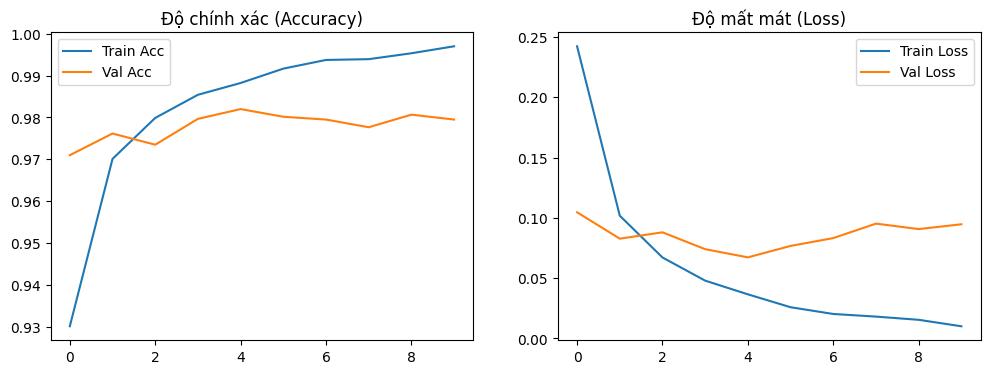


Kết quả dự báo trên tập kiểm thử:


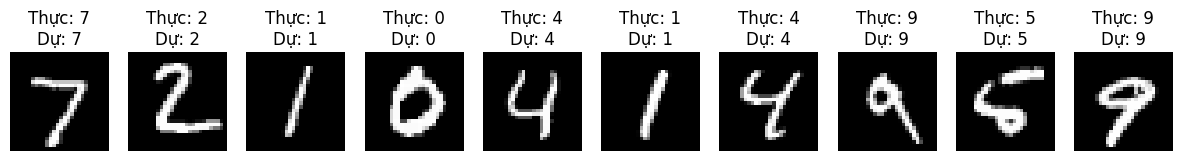

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 1. Tải dữ liệu
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train, X_test = X_train.astype('float32') / 255.0, X_test.astype('float32') / 255.0

# 2. Xây dựng mô hình
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu', kernel_initializer='uniform'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Huấn luyện
print("Đang huấn luyện...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# 4. TRỰC QUAN HÓA (Phần bạn yêu cầu)
# 4.1 Vẽ đồ thị Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Độ chính xác (Accuracy)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Độ mất mát (Loss)')
plt.legend()
plt.show()

# 4.2 HIỂN THỊ ẢNH DỰ BÁO (Kết quả thực tế vs Dự đoán)
plt.figure(figsize=(15, 3))
print("\nKết quả dự báo trên tập kiểm thử:")
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[i], cmap='gray')

    # Dự báo
    img_array = X_test[i].reshape(1, 28, 28)
    pred = np.argmax(model.predict(img_array, verbose=0))

    plt.title(f"Thực: {y_test[i]}\nDự: {pred}")
    plt.axis('off')
plt.show()

Đang huấn luyện mô hình Chó/Mèo...
Epoch 1/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5502 - loss: 0.7023 - val_accuracy: 0.5750 - val_loss: 0.6750
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5788 - loss: 0.6734 - val_accuracy: 0.5250 - val_loss: 0.7000
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5828 - loss: 0.6712 - val_accuracy: 0.5790 - val_loss: 0.6711
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5943 - loss: 0.6632 - val_accuracy: 0.5820 - val_loss: 0.6689
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5998 - loss: 0.6635 - val_accuracy: 0.5670 - val_loss: 0.6706
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5957 - loss: 0.6606 - val_accuracy: 0.5560 - val_loss: 0.6809
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5967 - loss: 0.6619 - val_accuracy: 0.5790 - val_loss: 0.6694
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6

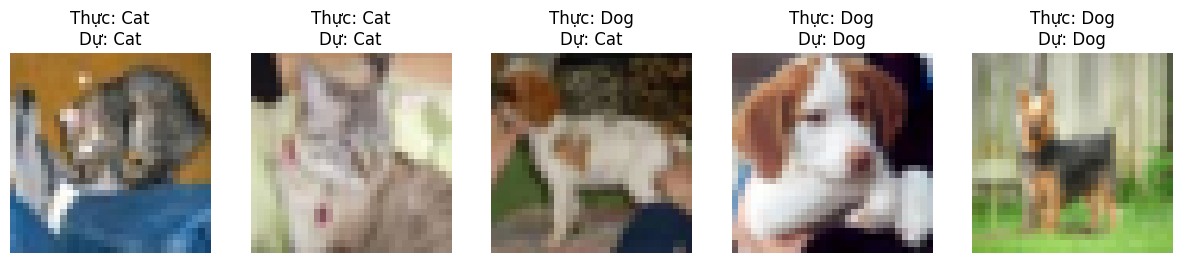

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 1. Tải CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Lọc chỉ lấy Chó (5) và Mèo (3)
# Trong CIFAR-10: 3 là Mèo, 5 là Chó
idx_train = np.where((y_train == 3) | (y_train == 5))[0]
idx_test = np.where((y_test == 3) | (y_test == 5))[0]

X_train, y_train = X_train[idx_train], y_train[idx_train]
X_test, y_test = X_test[idx_test], y_test[idx_test]

# Gán lại nhãn: Mèo = 0, Chó = 1
y_train = np.where(y_train == 3, 0, 1)
y_test = np.where(y_test == 3, 0, 1)

X_train, X_test = X_train.astype('float32') / 255.0, X_test.astype('float32') / 255.0

# 3. Kiến trúc ANN (Phân lớp nhị phân)
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Dùng Sigmoid cho 2 lớp
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Huấn luyện
print("Đang huấn luyện mô hình Chó/Mèo...")
model.fit(X_train, y_train, epochs=15, validation_split=0.1, verbose=1)

# 5. Hiển thị ảnh dự báo
plt.figure(figsize=(15, 3))
print("\nKết quả dự báo:")
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i])
    pred = model.predict(X_test[i:i+1], verbose=0)

    # Chuyển đổi nhãn về tên
    label_pred = "Dog" if pred > 0.5 else "Cat"
    label_true = "Dog" if y_test[i] == 1 else "Cat"

    plt.title(f"Thực: {label_true}\nDự: {label_pred}")
    plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Đang huấn luyện mô hình Xe hơi/Xe tải...
Epoch 1/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6534 - loss: 0.6282 - val_accuracy: 0.6740 - val_loss: 0.5937
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6753 - loss: 0.5955 - val_accuracy: 0.7010 - val_loss: 0.5734
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6913 - loss: 0.5889 - val_accuracy: 0.7080 - val_loss: 0.5775
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7030 - loss: 0.5681 - val_accuracy: 0.7200 - val_loss: 0.5653
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7159 - loss: 0.5550 - val_accuracy: 0.6660 - val_loss: 0.6158
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7292 - loss: 0.5411 - val_accuracy: 0.6790 - val_loss: 0.5827
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7269 - loss: 0.5374 - val_accuracy: 0.6550 - val_loss: 0.6101
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

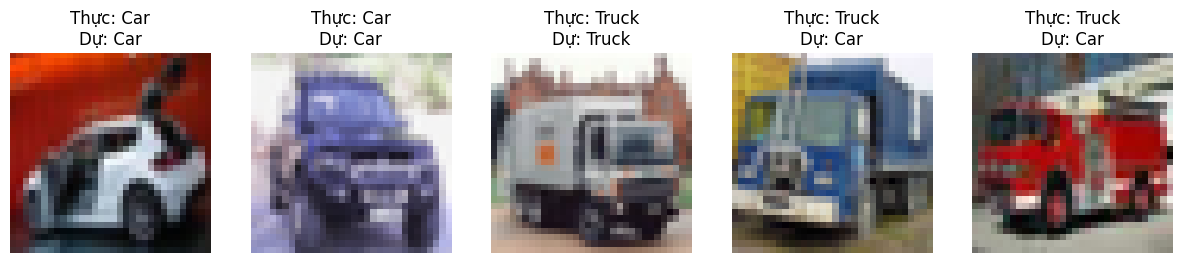

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 1. Tải CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Lọc chỉ lấy Xe hơi (1) và Xe tải (9)
# Trong CIFAR-10: 1 là Car, 9 là Truck
idx_train = np.where((y_train == 1) | (y_train == 9))[0]
idx_test = np.where((y_test == 1) | (y_test == 9))[0]

X_train, y_train = X_train[idx_train], y_train[idx_train]
X_test, y_test = X_test[idx_test], y_test[idx_test]

# Gán lại nhãn: Car = 0, Truck = 1
y_train = np.where(y_train == 1, 0, 1)
y_test = np.where(y_test == 1, 0, 1)

X_train, X_test = X_train.astype('float32') / 255.0, X_test.astype('float32') / 255.0

# 3. Kiến trúc ANN (Phân lớp nhị phân)
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Dùng Sigmoid cho 2 lớp
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Huấn luyện
print("Đang huấn luyện mô hình Xe hơi/Xe tải...")
model.fit(X_train, y_train, epochs=15, validation_split=0.1, verbose=1)

# 5. Hiển thị ảnh dự báo
plt.figure(figsize=(15, 3))
print("\nKết quả dự báo:")
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i])
    pred = model.predict(X_test[i:i+1], verbose=0)

    # Chuyển đổi nhãn về tên
    label_pred = "Truck" if pred > 0.5 else "Car"
    label_true = "Truck" if y_test[i] == 1 else "Car"

    plt.title(f"Thực: {label_true}\nDự: {label_pred}")
    plt.axis('off')
plt.show()

Đang huấn luyện mô hình dự báo thu nhập...
Epoch 1/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8211 - loss: 0.3853 - val_accuracy: 0.8425 - val_loss: 0.3401
Epoch 2/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8418 - loss: 0.3372 - val_accuracy: 0.8394 - val_loss: 0.3379
Epoch 3/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8442 - loss: 0.3311 - val_accuracy: 0.8444 - val_loss: 0.3348
Epoch 4/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8462 - loss: 0.3276 - val_accuracy: 0.8427 - val_loss: 0.3341
Epoch 5/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8466 - loss: 0.3254 - val_accuracy: 0.8417 - val_loss: 0.3349
Epoch 6/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8468 - loss: 0.3237 - val_accuracy: 0.8378 - val_loss: 0.3351
Epoch 7/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8484 - loss: 0.3211 - val_accuracy: 0.8427 - val_loss: 0.3318
Epoch 8/20
604/604 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accurac

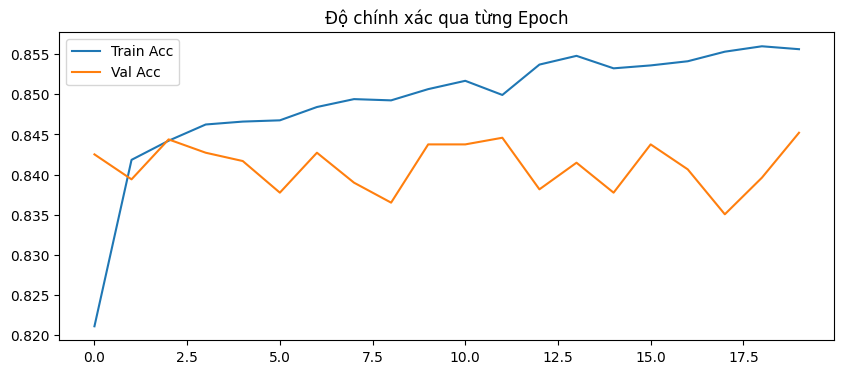


--- KẾT QUẢ DỰ BÁO ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Mẫu 1 -> Thực tế: >50K | Dự báo: <=50K
Mẫu 2 -> Thực tế: <=50K | Dự báo: <=50K
Mẫu 3 -> Thực tế: >50K | Dự báo: <=50K
Mẫu 4 -> Thực tế: <=50K | Dự báo: <=50K
Mẫu 5 -> Thực tế: <=50K | Dự báo: <=50K


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Tải và xử lý dữ liệu Adult
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns, skipinitialspace=True)

# Loại bỏ giá trị thiếu (nếu có)
df = df.replace('?', np.nan).dropna()

# Mã hóa dữ liệu chữ thành số
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Chia X, y
X = df.drop('income', axis=1).values
y = df['income'].values

# Chuẩn hóa dữ liệu (quan trọng cho các cột có số lớn như fnlwgt)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Xây dựng mô hình ANN
model = Sequential([
    Input(shape=(14,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Phân loại nhị phân (>50k hoặc <=50k)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Huấn luyện
print("Đang huấn luyện mô hình dự báo thu nhập...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 4. Hiển thị kết quả
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Độ chính xác qua từng Epoch')
plt.legend()
plt.show()

# 5. Dự báo thử nghiệm
print("\n--- KẾT QUẢ DỰ BÁO ---")
preds = (model.predict(X_test[:5]) > 0.5).astype("int32")
for i in range(5):
    true_val = ">50K" if y_test[i] == 1 else "<=50K"
    pred_val = ">50K" if preds[i] == 1 else "<=50K"
    print(f"Mẫu {i+1} -> Thực tế: {true_val} | Dự báo: {pred_val}")